In [2]:
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')   

MODEL_PATH = Path("../models/xgb_readmission_pipeline.pkl")

pipeline = joblib.load(MODEL_PATH)

print(type(pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [3]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

## loading processed dataset
df = pd.read_csv("../dataset/processed/cleaned_diabetic_data.csv")
df.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'target'],
      dtype='str')

In [5]:
# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

In [6]:
# Create calibration split
X_train, X_calib, y_train, y_calib = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Calibration set shape:", X_calib.shape)

Calibration set shape: (20353, 38)


In [7]:
from sklearn.metrics import roc_auc_score, brier_score_loss

# Raw probability predictions
raw_probs = pipeline.predict_proba(X_calib)[:, 1]

# Basic evaluation
roc_auc = roc_auc_score(y_calib, raw_probs)
brier = brier_score_loss(y_calib, raw_probs)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Brier Score: {brier:.4f}")

ROC-AUC: 0.6902
Brier Score: 0.2163


In [9]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Freeze already-trained pipeline
frozen_pipeline = FrozenEstimator(pipeline)

# Sigmoid / Platt Scaling
sigmoid_calibrator = CalibratedClassifierCV(
    estimator=frozen_pipeline,
    method="sigmoid"
)

sigmoid_calibrator.fit(X_calib, y_calib)

# Isotonic Regression
isotonic_calibrator = CalibratedClassifierCV(
    estimator=frozen_pipeline,
    method="isotonic"
)

isotonic_calibrator.fit(X_calib, y_calib)

print("Calibration models fitted successfully.")

Calibration models fitted successfully.


In [10]:
# Generate calibrated probabilities
sigmoid_probs = sigmoid_calibrator.predict_proba(X_calib)[:, 1]
isotonic_probs = isotonic_calibrator.predict_proba(X_calib)[:, 1]

# Evaluate all models
results = {
    "Raw XGBoost": {
        "ROC-AUC": roc_auc_score(y_calib, raw_probs),
        "Brier": brier_score_loss(y_calib, raw_probs)
    },
    "Sigmoid Calibration": {
        "ROC-AUC": roc_auc_score(y_calib, sigmoid_probs),
        "Brier": brier_score_loss(y_calib, sigmoid_probs)
    },
    "Isotonic Calibration": {
        "ROC-AUC": roc_auc_score(y_calib, isotonic_probs),
        "Brier": brier_score_loss(y_calib, isotonic_probs)
    }
}

# Print results
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    print(f"ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print(f"Brier Score: {metrics['Brier']:.4f}")


Raw XGBoost
ROC-AUC: 0.6902
Brier Score: 0.2163

Sigmoid Calibration
ROC-AUC: 0.6902
Brier Score: 0.0935

Isotonic Calibration
ROC-AUC: 0.6932
Brier Score: 0.0931


In [12]:
!pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 682.7 kB/s eta 0:00:01
     ------------------------------------ - 51.2/52.8 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 546.1 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ------------------- ------------------- 61.4/121.0 kB 1.6 MB/s eta 0:00:01
     -------------------------------------- 121.0/121.0 kB 2.4 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB 6.5 MB/s eta 0:00:02
   --- ------------------------------------ 0.7/8.2 MB 7.9 MB/s eta 0:00:01
   ----- --------------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


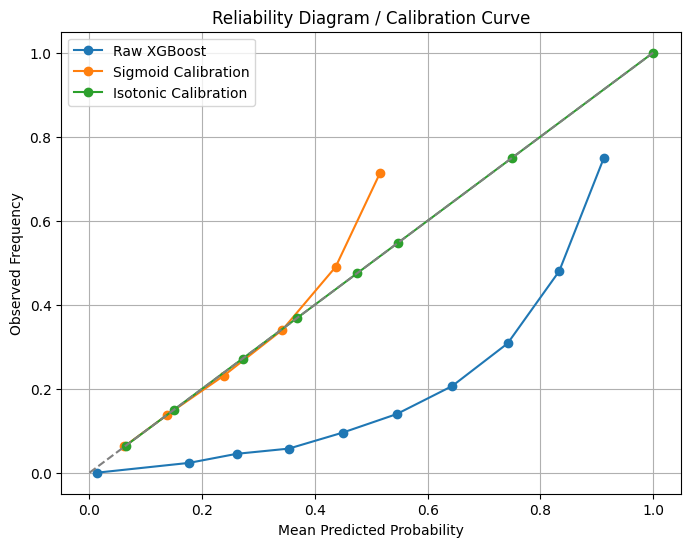

In [13]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Calibration curves
raw_true, raw_pred = calibration_curve(y_calib, raw_probs, n_bins=10)
sig_true, sig_pred = calibration_curve(y_calib, sigmoid_probs, n_bins=10)
iso_true, iso_pred = calibration_curve(y_calib, isotonic_probs, n_bins=10)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(raw_pred, raw_true, marker='o', label='Raw XGBoost')
plt.plot(sig_pred, sig_true, marker='o', label='Sigmoid Calibration')
plt.plot(iso_pred, iso_true, marker='o', label='Isotonic Calibration')

# Perfect calibration reference
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Reliability Diagram / Calibration Curve")
plt.legend()

plt.grid(True)
plt.show()

In [14]:
import joblib
from pathlib import Path

SAVE_PATH = Path("../models/xgb_calibrated_pipeline.pkl")

joblib.dump(isotonic_calibrator, SAVE_PATH)

print(f"Calibrated model saved to: {SAVE_PATH}")

Calibrated model saved to: ..\models\xgb_calibrated_pipeline.pkl


In [15]:
import joblib

# Reload calibrated model
loaded_calibrated_model = joblib.load(
    "../models/xgb_calibrated_pipeline.pkl"
)

# Test inference
sample_probs = loaded_calibrated_model.predict_proba(X_calib.iloc[:5])[:, 1]

print(sample_probs)

[0.09431818 0.05052265 0.08376194 0.18898071 0.05539569]


In [16]:
def assign_risk_band(prob):
    """
    Assign clinical risk category based on calibrated probability.
    """

    if prob < 0.30:
        return "Low Risk"

    elif prob < 0.65:
        return "Moderate Risk"

    return "High Risk"


sample_probabilities = [0.12, 0.47, 0.81]

for prob in sample_probabilities:
    print(f"{prob:.2f} --> {assign_risk_band(prob)}")

0.12 --> Low Risk
0.47 --> Moderate Risk
0.81 --> High Risk


In [17]:
# Apply risk band policy on calibrated probabilities
risk_bands = [assign_risk_band(prob) for prob in isotonic_probs]

# Convert to dataframe for inspection
import pandas as pd

risk_analysis_df = pd.DataFrame({
    "Actual": y_calib.values,
    "Calibrated_Probability": isotonic_probs,
    "Risk_Band": risk_bands
})

risk_analysis_df.head()

,Actual,Calibrated_Probability,Risk_Band
0,1,0.094318,Low Risk
1,0,0.050523,Low Risk
2,0,0.083762,Low Risk
3,1,0.188981,Low Risk
4,0,0.055396,Low Risk


In [18]:
# Distribution of patients across risk bands
risk_analysis_df["Risk_Band"].value_counts()

Risk_Band
Low Risk         20055
Moderate Risk      292
High Risk            6
Name: count, dtype: int64

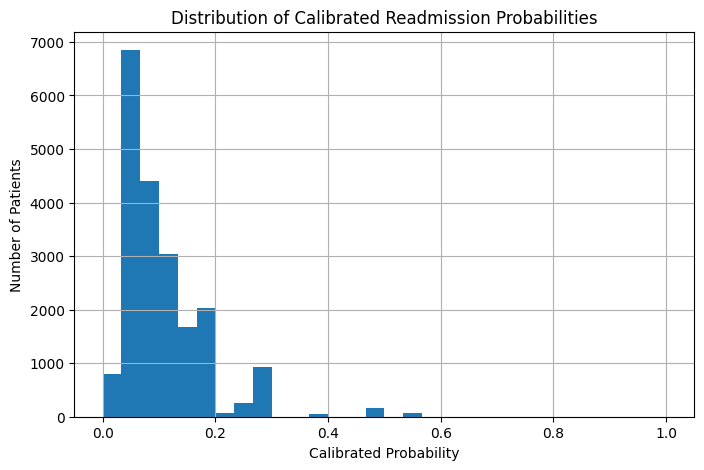

In [19]:
import matplotlib.pyplot as plt

# Plot calibrated probability distribution
plt.figure(figsize=(8, 5))

plt.hist(isotonic_probs, bins=30)

plt.xlabel("Calibrated Probability")
plt.ylabel("Number of Patients")
plt.title("Distribution of Calibrated Readmission Probabilities")

plt.grid(True)
plt.show()

In [20]:
# Inspect probability percentiles
import numpy as np

percentiles = [50, 75, 90, 95, 99]

for p in percentiles:
    value = np.percentile(isotonic_probs, p)
    print(f"{p}th percentile: {value:.4f}")

50th percentile: 0.0935
75th percentile: 0.1545
90th percentile: 0.1890
95th percentile: 0.2871
99th percentile: 0.4750


In [21]:
def assign_risk_band(prob):
    """
    Clinical risk stratification using calibrated probability distribution.
    """

    if prob < 0.15:
        return "Low Risk"

    elif prob < 0.30:
        return "Moderate Risk"

    return "High Risk"

risk_bands = [assign_risk_band(prob) for prob in isotonic_probs]

risk_analysis_df = pd.DataFrame({
    "Actual": y_calib.values,
    "Calibrated_Probability": isotonic_probs,
    "Risk_Band": risk_bands
})

risk_analysis_df["Risk_Band"].value_counts()

Risk_Band
Low Risk         15091
Moderate Risk     4964
High Risk          298
Name: count, dtype: int64

In [22]:
# Actual readmission rate inside each risk band
band_performance = (
    risk_analysis_df
    .groupby("Risk_Band")["Actual"]
    .mean()
    .sort_values()
)

print(band_performance)

Risk_Band
Low Risk         0.075873
Moderate Risk    0.198026
High Risk        0.479866
Name: Actual, dtype: float64


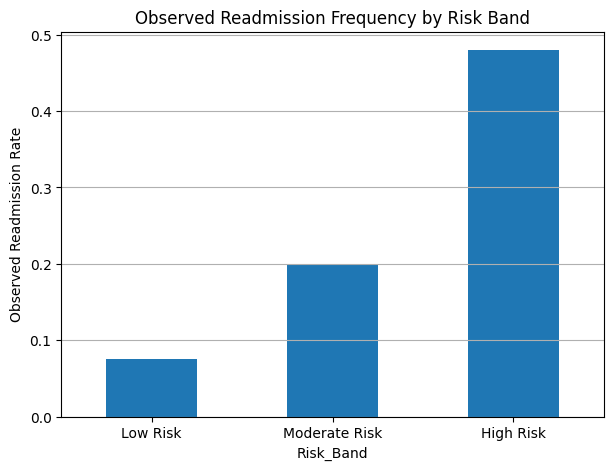

In [23]:
import matplotlib.pyplot as plt

# Plot observed readmission rate by risk band
band_performance.plot(kind="bar", figsize=(7, 5))

plt.ylabel("Observed Readmission Rate")
plt.title("Observed Readmission Frequency by Risk Band")
plt.xticks(rotation=0)

plt.grid(axis="y")
plt.show()